# Portafolio de Estadística: Intervalos de Confianza
**Enlace al Dataset original:** [https://www.umesc.usgs.gov/data_library/fisheries/fish1_query.html]
**Dataset de trabajo:** `ltrm_fish_data.csv`
<div align="center">
  <a href="https://www.umesc.usgs.gov/data_library/fisheries/fish1_query.html">
    <img src="https://img.shields.io/badge/-🗄️_Ir_a_la_Base_de_Datos-238636?style=for-the-badge" alt="Botón Base de Datos" />
  </a>
</div>

<div align="center">
  <a href="https://axiscrazy.github.io/Probabilidad-y-estadistica-2/index.html">
    <img src="https://img.shields.io/badge/-⬅️_Regresar_a_la_página_web-007ACC?style=for-the-badge" alt="Botón Regresar" />
  </a>
</div>

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

# Cargar el dataset limpio
df = pd.read_csv('df_limpio.csv')

columna_analisis = 'weight' 

# Mostrar las primeras filas para verificar
df.head()

,fishcode,length,temp,depth,cond,do,secchi,weight
0,LMBS,174.0,21.8,0.8,348.0,8.6,80.0,75.0
1,LMBS,124.0,21.8,0.8,348.0,8.6,80.0,29.0
2,BLGL,149.0,21.8,0.8,348.0,8.6,80.0,84.0
3,BLGL,165.0,21.8,0.8,348.0,8.6,80.0,119.0
4,BLGL,151.0,21.8,0.8,348.0,8.6,80.0,82.0


#### Tabla Z (Distribución Normal Estándar)
<img src="tabla_z.png" alt="Tabla Z" width="800"/>

<br>

### Problema 1: Muestra mayor a 30 (Uso de Distribución Z)
Se extrae una muestra grande ($n > 30$) para calcular un intervalo de confianza del 95%.
Como $n \ge 30$, podemos utilizar la aproximación a la normal (Tabla Z).

**Fórmula del Intervalo de Confianza:**
$$ \bar{x} \pm Z_{\alpha/2} \frac{s}{\sqrt{n}} $$

**Donde:**
- $\bar{x}$: Media muestral (estimador puntual).
- $Z_{\alpha/2}$: Valor crítico de la distribución normal estándar asociado al nivel de confianza.
- $s$: Desviación estándar de la muestra.
- $n$: Tamaño de la muestra.

---
**Cálculo manual (Sustitución paso a paso):**
De acuerdo a los datos obtenidos de nuestra muestra:
- $\bar{x} = 730.2075$
- $Z_{0.025} = 1.96$
- $n = 40$
- $s \approx 1539.61$ *(Desviación estándar calculada por Python)*

Sustituyendo en la fórmula:
$$ 730.2075 \pm 1.96 \left( \frac{1539.61}{\sqrt{40}} \right) $$

$$ 730.2075 \pm 1.96 \left( \frac{1539.61}{6.3245} \right) $$

$$ 730.2075 \pm 1.96 (243.435) $$

$$ 730.2075 \pm 477.13 $$

**Resultado final:**
- **Límite inferior:** $730.2075 - 477.13 = 253.0775$
- **Límite superior:** $730.2075 + 477.13 = 1207.3375$
- **Intervalo de Confianza (95%):** $(253.0775, 1207.3375)$

--- Problema 1: Muestra n=40 ---
Media muestral: 730.2075
Valor Z (95%): 1.9600
Intervalo de Confianza (95%): (253.0775, 1207.3375)


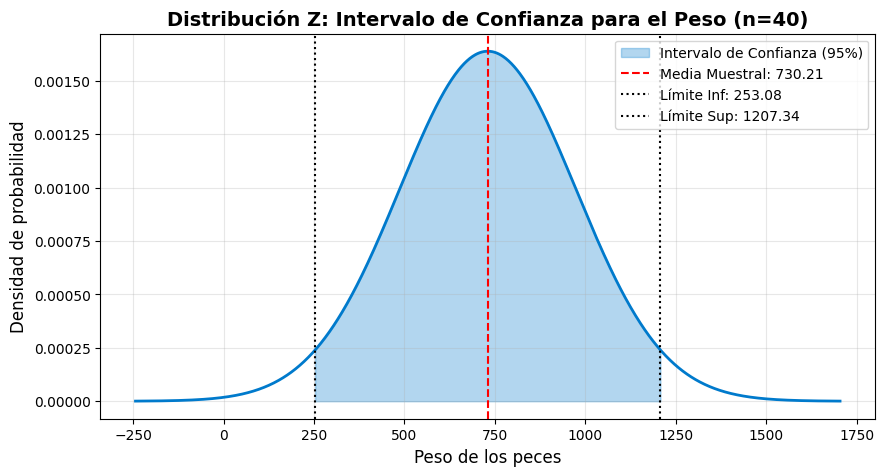

In [2]:
# Extraer muestra mayor a 30
muestra_1 = df[columna_analisis].sample(n=40, random_state=42)
n1 = len(muestra_1)
media1 = muestra_1.mean()
# Usamos la desviación estándar de la muestra como aproximación
std1 = muestra_1.std(ddof=1) 

# Nivel de confianza 95% -> alfa = 0.05 -> Z(0.025)
z_valor = st.norm.ppf(0.975) 
margen_error_z = z_valor * (std1 / np.sqrt(n1))
limite_inf_z = media1 - margen_error_z
limite_sup_z = media1 + margen_error_z

print(f"--- Problema 1: Muestra n={n1} ---")
print(f"Media muestral: {media1:.4f}")
print(f"Valor Z (95%): {z_valor:.4f}")
print(f"Intervalo de Confianza (95%): ({limite_inf_z:.4f}, {limite_sup_z:.4f})")

# --- GRÁFICA ---
error_estandar_1 = std1 / np.sqrt(n1)
x1 = np.linspace(media1 - 4*error_estandar_1, media1 + 4*error_estandar_1, 1000)
y1 = st.norm.pdf(x1, media1, error_estandar_1)

plt.figure(figsize=(10, 5))
plt.plot(x1, y1, color='#007ACC', linewidth=2)

x_fill = np.linspace(limite_inf_z, limite_sup_z, 500)
y_fill = st.norm.pdf(x_fill, media1, error_estandar_1)
plt.fill_between(x_fill, y_fill, color='#007ACC', alpha=0.3, label='Intervalo de Confianza (95%)')

plt.axvline(media1, color='red', linestyle='--', linewidth=1.5, label=f'Media Muestral: {media1:.2f}')
plt.axvline(limite_inf_z, color='black', linestyle=':', linewidth=1.5, label=f'Límite Inf: {limite_inf_z:.2f}')
plt.axvline(limite_sup_z, color='black', linestyle=':', linewidth=1.5, label=f'Límite Sup: {limite_sup_z:.2f}')

plt.title("Distribución Z: Intervalo de Confianza para el Peso (n=40)", fontsize=14, fontweight='bold')
plt.xlabel("Peso de los peces", fontsize=12)
plt.ylabel("Densidad de probabilidad", fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

### Análisis Global: Intervalo de Confianza con todos los datos del Dataset
Al utilizar la totalidad de los datos limpios, contamos con un tamaño de muestra $N$ muy grande. Esto nos permite usar la distribución Z. Al aumentar drásticamente el tamaño de la muestra, el error estándar disminuye, lo que resulta en un intervalo de confianza mucho más estrecho y preciso para la media poblacional.

--- Análisis con todos los datos (N=92222) ---
Media global: 624.3231
Desviación estándar global (s): 1166.4490
Valor Z (95%): 1.9600
Intervalo de Confianza (95%): (616.7948, 631.8514)



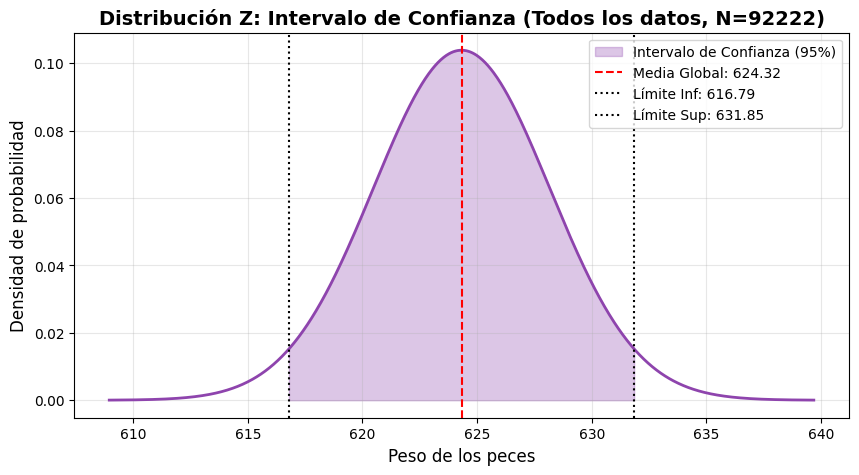

In [4]:
# Extraer todos los datos de la columna (eliminando posibles valores nulos por seguridad)
datos_completos = df[columna_analisis].dropna()
n_total = len(datos_completos)
media_total = datos_completos.mean()
std_total = datos_completos.std(ddof=1) 

# Nivel de confianza 95% -> Z(0.025)
z_valor_total = st.norm.ppf(0.975) 
margen_error_z_total = z_valor_total * (std_total / np.sqrt(n_total))
limite_inf_z_total = media_total - margen_error_z_total
limite_sup_z_total = media_total + margen_error_z_total

print(f"--- Análisis con todos los datos (N={n_total}) ---")
print(f"Media global: {media_total:.4f}")
print(f"Desviación estándar global (s): {std_total:.4f}")
print(f"Valor Z (95%): {z_valor_total:.4f}")
print(f"Intervalo de Confianza (95%): ({limite_inf_z_total:.4f}, {limite_sup_z_total:.4f})\n")

# --- GRÁFICA ---
error_estandar_total = std_total / np.sqrt(n_total)
x_total = np.linspace(media_total - 4*error_estandar_total, media_total + 4*error_estandar_total, 1000)
y_total = st.norm.pdf(x_total, media_total, error_estandar_total)

plt.figure(figsize=(10, 5))
# Dibujar la curva en color morado
plt.plot(x_total, y_total, color='#8E44AD', linewidth=2)

# Sombrear el área del intervalo
x_fill_total = np.linspace(limite_inf_z_total, limite_sup_z_total, 500)
y_fill_total = st.norm.pdf(x_fill_total, media_total, error_estandar_total)
plt.fill_between(x_fill_total, y_fill_total, color='#8E44AD', alpha=0.3, label='Intervalo de Confianza (95%)')

# Líneas guía
plt.axvline(media_total, color='red', linestyle='--', linewidth=1.5, label=f'Media Global: {media_total:.2f}')
plt.axvline(limite_inf_z_total, color='black', linestyle=':', linewidth=1.5, label=f'Límite Inf: {limite_inf_z_total:.2f}')
plt.axvline(limite_sup_z_total, color='black', linestyle=':', linewidth=1.5, label=f'Límite Sup: {limite_sup_z_total:.2f}')

# Estilos
plt.title(f"Distribución Z: Intervalo de Confianza (Todos los datos, N={n_total})", fontsize=14, fontweight='bold')
plt.xlabel("Peso de los peces", fontsize=12)
plt.ylabel("Densidad de probabilidad", fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

#### Tabla T de Student
<img src="tabla_t_1.png" alt="Tabla T de Student" width="800"/>
<img src="tabla_t_2.png" alt="Tabla T de Student" width="800"/>

### Problema 2 y 3: Muestra menor a 30 y sin desviación estándar poblacional
Se extrae una muestra pequeña ($n < 30$). Al no conocer la desviación estándar de la población ($\sigma$), se utiliza la desviación estándar muestral ($s$) y la distribución **T de Student** con $n-1$ grados de libertad.
Se solicita un nivel de confianza del **95%**.

**Fórmula del Intervalo de Confianza:**
$$ \bar{x} \pm t_{\alpha/2, n-1} \frac{s}{\sqrt{n}} $$

**Donde:**
- $\bar{x}$: Media muestral (estimador puntual).
- $t_{\alpha/2, n-1}$: Valor crítico de la distribución T de Student con $n-1$ grados de libertad.
- $s$: Desviación estándar de la muestra.
- $n$: Tamaño de la muestra.

---
**Cálculo manual (Sustitución paso a paso):**
De acuerdo a los datos obtenidos de nuestra muestra:
- $\bar{x} = 726.8500$
- $s = 1636.7442$
- $n = 20$ *(Por lo tanto, Grados de libertad = 19)*
- $t_{0.025, 19} = 2.0930$

Sustituyendo en la fórmula:
$$ 726.8500 \pm 2.0930 \left( \frac{1636.7442}{\sqrt{20}} \right) $$

$$ 726.8500 \pm 2.0930 \left( \frac{1636.7442}{4.4721} \right) $$

$$ 726.8500 \pm 2.0930 (366.012) $$

$$ 726.8500 \pm 766.0199 $$

**Resultado final:**
- **Límite inferior:** $726.8500 - 766.0199 = -39.1699$
- **Límite superior:** $726.8500 + 766.0199 = 1492.8699$
- **Intervalo de Confianza (95%):** $(-39.1699, 1492.8699)$

*(Nota: Que el límite inferior salga negativo es una consecuencia matemática de tener una desviación estándar muestral muy alta respecto a la media. En la realidad física, el peso de un pez no puede ser negativo, indicando que los datos están fuertemente sesgados o tienen mucha dispersión).*

--- Problema 2 y 3: Muestra n=20 ---
Grados de libertad (df): 19
Media muestral: 726.8500
Desviación est. muestral (s): 1636.7442
Valor T (95%): 2.0930
Intervalo de Confianza T (95%): (-39.1699, 1492.8699)


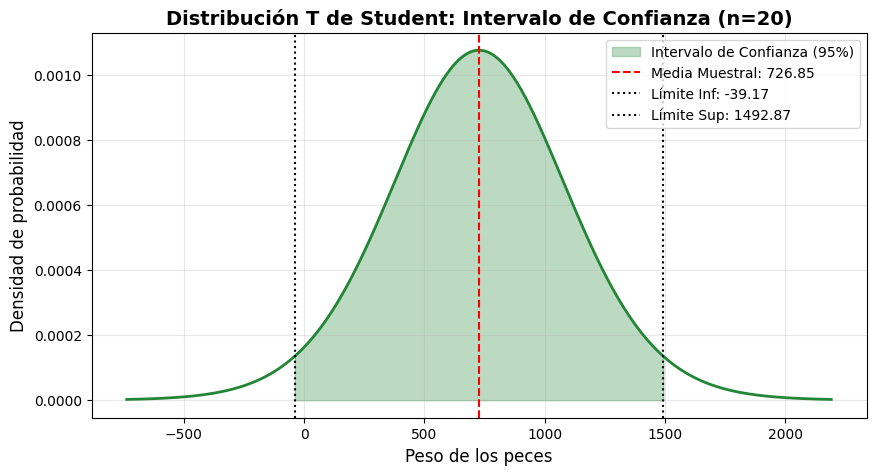

In [3]:
# Extraer muestra menor a 30
muestra_2 = df[columna_analisis].sample(n=20, random_state=42)
n2 = len(muestra_2)
grados_libertad = n2 - 1
media2 = muestra_2.mean()
std2_muestral = muestra_2.std(ddof=1) # Desviación estándar muestral (s)

# Nivel de confianza 95% para t-Student
t_valor = st.t.ppf(0.975, df=grados_libertad) 

margen_error_t = t_valor * (std2_muestral / np.sqrt(n2))
limite_inf_t = media2 - margen_error_t
limite_sup_t = media2 + margen_error_t

print(f"--- Problema 2 y 3: Muestra n={n2} ---")
print(f"Grados de libertad (df): {grados_libertad}")
print(f"Media muestral: {media2:.4f}")
print(f"Desviación est. muestral (s): {std2_muestral:.4f}")
print(f"Valor T (95%): {t_valor:.4f}")
print(f"Intervalo de Confianza T (95%): ({limite_inf_t:.4f}, {limite_sup_t:.4f})")

# --- GRÁFICA ---
error_estandar_2 = std2_muestral / np.sqrt(n2)
x2 = np.linspace(media2 - 4*error_estandar_2, media2 + 4*error_estandar_2, 1000)
y2 = st.t.pdf(x2, df=grados_libertad, loc=media2, scale=error_estandar_2)

plt.figure(figsize=(10, 5))
plt.plot(x2, y2, color='#238636', linewidth=2)

x_fill2 = np.linspace(limite_inf_t, limite_sup_t, 500)
y_fill2 = st.t.pdf(x_fill2, df=grados_libertad, loc=media2, scale=error_estandar_2)
plt.fill_between(x_fill2, y_fill2, color='#238636', alpha=0.3, label='Intervalo de Confianza (95%)')

plt.axvline(media2, color='red', linestyle='--', linewidth=1.5, label=f'Media Muestral: {media2:.2f}')
plt.axvline(limite_inf_t, color='black', linestyle=':', linewidth=1.5, label=f'Límite Inf: {limite_inf_t:.2f}')
plt.axvline(limite_sup_t, color='black', linestyle=':', linewidth=1.5, label=f'Límite Sup: {limite_sup_t:.2f}')

plt.title("Distribución T de Student: Intervalo de Confianza (n=20)", fontsize=14, fontweight='bold')
plt.xlabel("Peso de los peces", fontsize=12)
plt.ylabel("Densidad de probabilidad", fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

<div align="center">
  <a href="https://axiscrazy.github.io/Probabilidad-y-estadistica-2/index.html">
    <button style="background-color: #007ACC; color: white; border: none; padding: 10px 20px; font-size: 16px; font-weight: bold; border-radius: 5px; cursor: pointer;">
      ⬅️ Regresar a la página web
    </button>
  </a>
</div>